**Importing Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

**Reading Training Dataset**

In [2]:
data_train = pd.read_csv('data_train.csv')
data_train.head()

,ID,Unnamed: 0,RA_ICRS,DE_ICRS,Source,Plx,PM,pmRA,pmDE,Gmag,...,G-RP,pscol,Teff,Dist,Rad,Lum-Flame,Mass-Flame,Age-Flame,z-Flame,SpType-ELS
0,1,1,44.375187,2.895901,1.400000e+15,1.8937,16.954,7.031,-15.427,10.369156,...,0.163792,NaN,9348.7,679.7121,2.4642,25.817343,2.157,0.336,0.638083,A
1,2,2,42.959304,2.920459,1.550000e+15,2.9732,2.528,1.795,1.780,10.038978,...,0.304139,NaN,7520.7,339.8108,1.9321,10.527038,1.688,1.033,0.507551,A
2,3,3,44.031079,3.203683,1.610000e+15,2.2337,10.776,-3.151,-10.305,9.810181,...,0.338961,1.5956,7052.3,433.9715,2.9735,20.801886,1.923,1.124,0.368294,A
3,4,4,45.463599,3.138095,1.750000e+15,4.0179,10.053,1.828,9.885,8.163041,...,0.091842,NaN,9982.8,251.2483,2.2829,45.868046,2.447,0.320,0.509338,A
4,5,5,43.784164,3.486814,2.060000e+15,11.6458,32.355,29.688,-12.863,6.855547,...,0.257051,NaN,7192.3,85.7073,2.0194,9.909233,1.647,1.288,0.459583,A


In [3]:
data_train.shape

(148538, 29)

In [4]:
data_train.dtypes

ID              int64
Unnamed: 0      int64
RA_ICRS       float64
DE_ICRS       float64
Source        float64
Plx           float64
PM            float64
pmRA          float64
pmDE          float64
Gmag          float64
e_Gmag        float64
BPmag         float64
e_BPmag       float64
RPmag         float64
e_RPmag       float64
GRVSmag       float64
e_GRVSmag     float64
BP-RP         float64
BP-G          float64
G-RP          float64
pscol         float64
Teff          float64
Dist          float64
Rad           float64
Lum-Flame     float64
Mass-Flame    float64
Age-Flame     float64
z-Flame       float64
SpType-ELS     object
dtype: object

**Finding Missing Values**

In [5]:
data_train.isnull().sum()

ID                 0
Unnamed: 0         0
RA_ICRS            0
DE_ICRS            0
Source             0
Plx                0
PM                 0
pmRA               0
pmDE               0
Gmag               0
e_Gmag             0
BPmag              0
e_BPmag            0
RPmag              0
e_RPmag            0
GRVSmag        64054
e_GRVSmag      64054
BP-RP              0
BP-G               0
G-RP               0
pscol         143685
Teff               0
Dist               0
Rad                0
Lum-Flame       2995
Mass-Flame     12551
Age-Flame      38016
z-Flame         2995
SpType-ELS         0
dtype: int64

**Handling Missing Values**

Dropping Columns with large number of missing values

In [6]:
data_train = data_train.drop(columns=['GRVSmag','e_GRVSmag','pscol'])

Imputing missing values with median strategy

In [7]:
from sklearn.impute import SimpleImputer

impute_columns = ['Lum-Flame','Mass-Flame','Age-Flame','z-Flame']
imputer = SimpleImputer(strategy='median')
data_train[impute_columns] = imputer.fit_transform(data_train[impute_columns])

In [8]:
data_train.isnull().sum()

ID            0
Unnamed: 0    0
RA_ICRS       0
DE_ICRS       0
Source        0
Plx           0
PM            0
pmRA          0
pmDE          0
Gmag          0
e_Gmag        0
BPmag         0
e_BPmag       0
RPmag         0
e_RPmag       0
BP-RP         0
BP-G          0
G-RP          0
Teff          0
Dist          0
Rad           0
Lum-Flame     0
Mass-Flame    0
Age-Flame     0
z-Flame       0
SpType-ELS    0
dtype: int64

**Encoding Categorical Variable SpType-ELS**

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_train['SpType-ELS'] = le.fit_transform(data_train['SpType-ELS'])

In [10]:
data_train['SpType-ELS'].unique()

array([0, 1])

**Splitting the data into features(X) and target variable(y)**

In [11]:
X = data_train.drop(columns=['ID','Unnamed: 0','SpType-ELS'])
y = data_train['SpType-ELS']

**Splitting the data into training and validation set**

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

In [13]:
print('X_train shape: ',X_train.shape)
print('X_val shape: ',X_val.shape)

X_train shape:  (118830, 23)
X_val shape:  (29708, 23)


**Standardizing the Features**

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## **Modelling**

#### **Logistic Regression**

In [15]:
lr = LogisticRegression(random_state=42,max_iter=1000)

In [16]:
#Training the classifier
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [17]:
#Predicting on the validation set
y_pred_lr = lr.predict(X_val)

In [18]:
#Evaluating the Classifier
accuracy_lr = accuracy_score(y_val,y_pred_lr)
print("Logistic Regression Validation Accuracy:", accuracy_lr*100, '%')
print()
print(classification_report(y_val,y_pred_lr))

Logistic Regression Validation Accuracy: 99.3200484717921 %

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.99      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Applying Hyperparameter Tunning on Logistic Regression Model**

In [19]:
#Defining the hyperparameters grid for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

In [20]:
lr_grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42),
                              param_grid=lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

#Training the model with GridSearchCV
lr_grid_search.fit(X_train, y_train)
best_lr_classifier = lr_grid_search.best_estimator_

#Predicting and evaluating
y_pred_lr = best_lr_classifier.predict(X_val)
accuracy_lr = accuracy_score(y_val, y_pred_lr)
print("Logistic Regression Validation Accuracy After Tuning:", accuracy_lr*100, '%')
print("Best Hyperparameters:", lr_grid_search.best_params_)
print(classification_report(y_val, y_pred_lr))

Logistic Regression Validation Accuracy After Tuning: 99.35034334186078 %
Best Hyperparameters: {'C': 100, 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.99      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Cross-Validation to check performance**

In [21]:
lr_cv_scores = cross_val_score(best_lr_classifier, X_train,y_train,cv=5,scoring='accuracy')
print("Logistic Regression Cross-Validation Mean Accuracy", np.mean(lr_cv_scores)*100,'%')

Logistic Regression Cross-Validation Mean Accuracy 99.34780779264494 %


#### **KNeighbors Classifier (KNN)**

In [22]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [23]:
y_pred_knn = knn.predict(X_val)

In [24]:
accuracy_knn = accuracy_score(y_val,y_pred_knn)
print("KNeighbor Classifier Validation Accuracy:", accuracy_knn*100, '%')
print()
print(classification_report(y_val,y_pred_knn))

KNeighbor Classifier Validation Accuracy: 98.83196445401911 %

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.98      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Applying Hyperparameter Tunning on KNeighbor Classifier**

In [25]:
knn_param_grid = {
  'n_neighbors' : [3,5,7,9,11],
  'weights' : ['uniform','distance']
}

In [26]:
knn_grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=knn_param_grid, cv=5, scoring='accuracy',n_jobs=-1)

In [27]:
knn_grid_search.fit(X_train,y_train)
best_knn_classifier = knn_grid_search.best_estimator_

In [28]:
y_pred_knn = best_knn_classifier.predict(X_val)
accuracy_knn_new = accuracy_score(y_val,y_pred_knn)
print('KNeighbors Classifier Validation Accuracy', accuracy_knn_new*100,'%')
print()
print('Best Hyperparameter:',knn_grid_search.best_params_)
print()
print(classification_report(y_val,y_pred_knn))

KNeighbors Classifier Validation Accuracy 98.83869664736771 %

Best Hyperparameter: {'n_neighbors': 5, 'weights': 'distance'}

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.98      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Cross-Validation**

In [29]:
knn_cv_scores = cross_val_score(best_knn_classifier,X_train,y_train, cv=5, scoring='accuracy')
print("KNeighbors Classifier Cross-Validation Mean Accuracy:", np.mean(knn_cv_scores)*100,'%')

KNeighbors Classifier Cross-Validation Mean Accuracy: 98.86981402002861 %


#### **Random Forest Classifier**

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred_rf = rf.predict(X_val)

In [32]:
accuracy_rf = accuracy_score(y_val,y_pred_rf)
print("Random Forest Classifier Validation Accuracy:", accuracy_rf*100, '%')
print()
print(classification_report(y_val,y_pred_rf))

Random Forest Classifier Validation Accuracy: 99.65665813922175 %

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16044
           1       0.99      1.00      1.00     13664

    accuracy                           1.00     29708
   macro avg       1.00      1.00      1.00     29708
weighted avg       1.00      1.00      1.00     29708



**Applying Hyperparameter Tuning on Random Forest Classifier**

In [33]:
rf_param_grid = {
    'max_depth': [None,10,20],
    'min_samples_split': [2,5,10]
}

In [34]:
rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=rf_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [35]:
rf_grid_search.fit(X_train,y_train)
best_rf_classifier = rf_grid_search.best_estimator_

In [38]:
y_pred_rf = best_rf_classifier.predict(X_val)
accuracy_rf_new = accuracy_score(y_val,y_pred_rf)
print('Random Forest Classifier Validation Score:', accuracy_rf_new*100,'%')
print()
print("Best Hyperparameter:", rf_grid_search.best_params_)
print()
print(classification_report(y_val,y_pred_rf))

Random Forest Classifier Validation Score: 99.65329204254746 %

Best Hyperparameter: {'max_depth': 20, 'min_samples_split': 2}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16044
           1       0.99      1.00      1.00     13664

    accuracy                           1.00     29708
   macro avg       1.00      1.00      1.00     29708
weighted avg       1.00      1.00      1.00     29708



Cross-Validation

In [39]:
rf_cv_scores = cross_val_score(best_rf_classifier,X_train,y_train, cv=5, scoring='accuracy')
print("Random Forest Cross Validation Mean Score:", np.mean(rf_cv_scores)*100,'%')

Random Forest Cross Validation Mean Score: 99.65833543717918 %


#### **Decision Tree Classifier**

In [40]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [41]:
y_pred_dt = dt.predict(X_val)

In [42]:
accuracy_dt = accuracy_score(y_val,y_pred_dt)
print('Decision Tree Classifier Validation Score:', accuracy_dt*100,'%')
print()
print(classification_report(y_val,y_pred_dt))

Decision Tree Classifier Validation Score: 99.39746869530093 %

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.99      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Applying Hyperparameter Tuning on Decision Tree Classifier**

In [43]:
dt_param_grid = {
    'max_depth' : [3,5,7,10],
    'min_samples_split' : [2,5,10]
}

In [44]:
dt_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),param_grid=dt_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [45]:
dt_grid_search.fit(X_train,y_train)
best_dt_classifier = dt_grid_search.best_estimator_

In [46]:
y_pred_dt = best_dt_classifier.predict(X_val)
accuracy_dt_new = accuracy_score(y_val,y_pred_dt)
print('Decision Tree Classifier Validation Score:', accuracy_dt_new*100,'%')
print()
print("Best Hyperparameter:", dt_grid_search.best_params_)
print()
print(classification_report(y_val,y_pred_dt))

Decision Tree Classifier Validation Score: 99.57923791571294 %

Best Hyperparameter: {'max_depth': 7, 'min_samples_split': 2}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16044
           1       0.99      1.00      1.00     13664

    accuracy                           1.00     29708
   macro avg       1.00      1.00      1.00     29708
weighted avg       1.00      1.00      1.00     29708



**Cross-Validation**

In [47]:
dt_cv_scores = cross_val_score(best_dt_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("Decision Tree Classifier Mean Validation Accuracy:", np.mean(dt_cv_scores)*100,'%')

Decision Tree Classifier Mean Validation Accuracy: 99.5817554489607 %


#### **Support Vector Classifier**

In [48]:
svc = SVC(random_state=42)
svc.fit(X_train,y_train)

SVC(random_state=42)

In [49]:
y_pred_svc = svc.predict(X_val)

In [50]:
accuracy_svc = accuracy_score(y_val,y_pred_svc)
print("Support Vector Classifier Validation Accuracy:", accuracy_svc*100, '%')
print()
print(classification_report(y_val,y_pred_svc))

Support Vector Classifier Validation Accuracy: 99.4243974686953 %

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.99      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Applying Hyperparameter Tunning for Support Vector Classifier**

In [51]:
svc_param_grid = {
    'gamma' : [1,0.1,0.01],
    'kernel' : ['linear','rbf']
}

In [52]:
svc_grid_search = GridSearchCV(estimator=SVC(random_state=42),param_grid=svc_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [53]:
svc_grid_search.fit(X_train,y_train)
best_svc_classifier = svc_grid_search.best_estimator_

In [54]:
y_pred_svc = best_svc_classifier.predict(X_val)
accuracy_svc_new = accuracy_score(y_val,y_pred_svc)
print('Support Vector Classifier Validation Score:', accuracy_svc_new*100,'%')
print()
print("Best Hyperparameter:", svc_grid_search.best_params_)
print()
print(classification_report(y_val,y_pred_svc))

Support Vector Classifier Validation Score: 99.4176652753467 %

Best Hyperparameter: {'gamma': 0.1, 'kernel': 'rbf'}

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16044
           1       0.99      0.99      0.99     13664

    accuracy                           0.99     29708
   macro avg       0.99      0.99      0.99     29708
weighted avg       0.99      0.99      0.99     29708



**Cross-Validation**

In [55]:
svc_cv_scores = cross_val_score(best_svc_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("Support Vector Classifier Mean Validation Accuracy:", np.mean(svc_cv_scores)*100,'%')

Support Vector Classifier Mean Validation Accuracy: 99.42438778086343 %


#### **XGBoost Classifier**

In [56]:
xg = xgb.XGBClassifier(random_state=42)
xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [57]:
y_pred_xg = xg.predict(X_val)

In [58]:
accuracy_xg = accuracy_score(y_val,y_pred_xg)
print("XGBoost Classifier Validation Score:", accuracy_xg*100,'%')
print()
print(classification_report(y_val,y_pred_xg))

XGBoost Classifier Validation Score: 99.69031910596472 %

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16044
           1       1.00      1.00      1.00     13664

    accuracy                           1.00     29708
   macro avg       1.00      1.00      1.00     29708
weighted avg       1.00      1.00      1.00     29708



**Applying Hyperparameter Tunning for XGBoost Classifier**

In [59]:
xgb_param_grid = {
    'n_estimators': [50,100,200],
    'learning_rate': [0.01,0.1,0.2],
}

In [60]:
xgb_grid_search = GridSearchCV(estimator=xgb.XGBClassifier(random_state=42),param_grid=xgb_param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [61]:
xgb_grid_search.fit(X_train,y_train)
best_xgb_classifier = xgb_grid_search.best_estimator_

In [62]:
y_pred_xgb = best_xgb_classifier.predict(X_val)
accuracy_xgb_new = accuracy_score(y_val,y_pred_xgb)
print('XGBoost Classifier Validation Score:', accuracy_xgb_new*100,'%')
print()
print("Best Hyperparameter:", xgb_grid_search.best_params_)
print()
print(classification_report(y_val,y_pred_xgb))

XGBoost Classifier Validation Score: 99.68695300929042 %

Best Hyperparameter: {'learning_rate': 0.2, 'n_estimators': 200}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16044
           1       1.00      1.00      1.00     13664

    accuracy                           1.00     29708
   macro avg       1.00      1.00      1.00     29708
weighted avg       1.00      1.00      1.00     29708



**Cross-Validation**

In [63]:
xgb_cv_scores = cross_val_score(best_xgb_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("XGBoost Classifier Mean Validation Score:", np.mean(xgb_cv_scores)*100,'%')

XGBoost Classifier Mean Validation Score: 99.69031389379786 %


#### **Comparing Results and Selecting the Best Model**

In [69]:
print(f"Logistic Regression Classifier Validation Accuracy: {accuracy_lr*100:.2f} %")
print(f"KNeighbors Classifier Validation Accuracy: {accuracy_knn_new*100:.2f} %")
print(f"Random Forest Classifier Validation Accuracy: {accuracy_rf_new*100:.2f} %")
print(f"Decision Tree Classifier Validation Accuracy: {accuracy_dt_new*100:.2f} %")
print(f"Support Vector Classifier Validation Accuracy: {accuracy_svc_new*100:.2f} %")
print(f"XGBoost Classifier Validation Accuracy: {accuracy_xgb_new*100:.2f} %")

Logistic Regression Classifier Validation Accuracy: 99.35 %
KNeighbors Classifier Validation Accuracy: 98.84 %
Random Forest Classifier Validation Accuracy: 99.65 %
Decision Tree Classifier Validation Accuracy: 99.58 %
Support Vector Classifier Validation Accuracy: 99.42 %
XGBoost Classifier Validation Accuracy: 99.69 %


#### **The Best Model**

Finding best model

In [70]:
best_model = max([(accuracy_lr,best_lr_classifier),
                 (accuracy_knn_new,best_knn_classifier),
                 (accuracy_rf_new,best_rf_classifier),
                 (accuracy_dt_new,best_dt_classifier),
                 (accuracy_svc_new,best_svc_classifier),
                 (accuracy_xgb_new,best_xgb_classifier)], key=lambda x:x[0])[1]
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### **ROC Curve & AUC Analysis**

Predicting Probabilities of the best model

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = best_xgb_classifier.predict_proba(X_val)[:,1]

Computing ROC curve and AUC Score

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val,y_pred_prob, pos_label='A')
auc_score = roc_auc_score(y_val,y_pred_prob)

Plotting ROC Curve

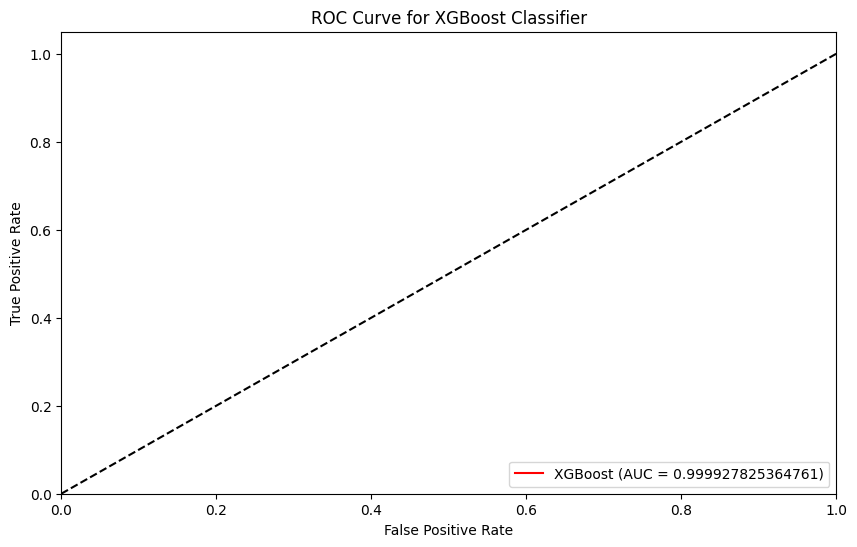

In [98]:
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score})', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Classifier')
plt.legend(loc='lower right')
plt.show()

### **Reading and Preprocessing Unknown Dataset File**

In [71]:
data_unknown = pd.read_csv('data_unknown.csv')
data_unknown.head()

,ID,Unnamed: 0,RA_ICRS,DE_ICRS,Source,Plx,PM,pmRA,pmDE,Gmag,...,BP-G,G-RP,pscol,Teff,Dist,Rad,Lum-Flame,Mass-Flame,Age-Flame,z-Flame
0,119089,19089,64.085883,46.209497,2.340000e+17,0.3386,1.067,-0.841,-0.656,13.132349,...,0.272599,0.444520,NaN,11663.4,2031.7985,2.8537,239.107820,3.514,NaN,0.515510
1,24912,24912,14.701590,67.754101,5.270000e+17,1.6877,3.527,-1.976,-2.921,12.781258,...,0.504253,0.678857,NaN,7661.9,615.7902,1.7595,9.183199,1.665,0.749,0.661103
2,6264,6264,55.953330,38.656112,2.240000e+17,0.8378,8.216,6.574,-4.927,12.053966,...,0.196862,0.331098,NaN,7820.4,1254.6984,2.9247,23.100883,1.986,0.920,0.322678
3,81903,81903,91.211868,-14.372262,2.990000e+18,1.1175,12.945,7.306,10.687,11.559693,...,0.126262,0.251504,NaN,8984.8,890.9888,2.2170,26.935236,2.133,0.499,0.516520
4,110917,10917,75.949263,40.560254,2.010000e+17,0.9456,5.200,3.248,-4.061,15.013525,...,0.252923,0.483553,NaN,10195.4,5160.0750,3.3666,111.986990,2.916,0.319,0.441721


In [72]:
data_unknown.shape

(37135, 28)

In [73]:
data_unknown.dtypes

ID              int64
Unnamed: 0      int64
RA_ICRS       float64
DE_ICRS       float64
Source        float64
Plx           float64
PM            float64
pmRA          float64
pmDE          float64
Gmag          float64
e_Gmag        float64
BPmag         float64
e_BPmag       float64
RPmag         float64
e_RPmag       float64
GRVSmag       float64
e_GRVSmag     float64
BP-RP         float64
BP-G          float64
G-RP          float64
pscol         float64
Teff          float64
Dist          float64
Rad           float64
Lum-Flame     float64
Mass-Flame    float64
Age-Flame     float64
z-Flame       float64
dtype: object

**Finding Missing Values**

In [74]:
data_unknown.isnull().sum()

ID                0
Unnamed: 0        0
RA_ICRS           0
DE_ICRS           0
Source            0
Plx               0
PM                0
pmRA              0
pmDE              0
Gmag              0
e_Gmag            0
BPmag             0
e_BPmag           0
RPmag             0
e_RPmag           0
GRVSmag       16230
e_GRVSmag     16230
BP-RP             0
BP-G              0
G-RP              0
pscol         35973
Teff              0
Dist              0
Rad               0
Lum-Flame       805
Mass-Flame     3246
Age-Flame      9629
z-Flame         805
dtype: int64

**Handling Missing Values**

Dropping Columns with large number of missing values

In [75]:
data_unknown = data_unknown.drop(columns=['GRVSmag','e_GRVSmag','pscol'])

Imputing Missing Values with Median Strategy

In [76]:
from sklearn.impute import SimpleImputer
impute_columns = ['Lum-Flame','Mass-Flame','Age-Flame','z-Flame']
imputer = SimpleImputer(strategy='median')
data_unknown[impute_columns] = imputer.fit_transform(data_unknown[impute_columns])

In [77]:
data_unknown.isnull().sum().any()

False

In [78]:
X_unknown = data_unknown.drop(columns=['ID','Unnamed: 0'])
X_unknown = scaler.transform(X_unknown)

In [79]:
y_pred_unknown = best_model.predict(X_unknown)
y_pred_unknown

array([1, 0, 0, ..., 1, 1, 1])

### **Preparing Submission File**

Mapping the predicted values to corresponding labels

In [82]:
label_mapping = {0: 'A', 1: 'B'}
y_pred_unknown_mapped = [label_mapping[pred] for pred in y_pred_unknown]

In [83]:
submission_data = pd.DataFrame({'ID': data_unknown['ID'],'SpType-ELS':y_pred_unknown_mapped})
submission_data.to_csv('submission.csv', index=False)